## Multi-protocol CNN Raw CSI Experiments

This notebook runs the fixed-capacity CNN across block, LOVO, and cross-session protocols with one independent run per configured seed.

In [1]:
from __future__ import annotations

import pandas as pd
import torch

from utils.config import (
    ANCHOR_GROUPS,
    ARCHITECTURE,
    BANDS_TO_RUN,
    DATA_DIR,
    DEFAULT_CNN_PARAMS,
    DEFAULT_OVERLAP_SIZE,
    DEFAULT_WINDOW_SIZE,
    EXPECTED_ANCHORS,
    EXPECTED_SUBCARRIERS,
    SEEDS,
)
from utils.DL.dl_pipeline import (
    create_position_label_encoder,
    get_cache_path,
    get_results_path,
    prepare_dl_data,
    print_torch_environment,
    run_dl_experiments,
    show_dl_results,
)
from utils.ML.ml_pipeline import (
    best_confusion_predictions,
    lovo_aggregated_analysis_table,
    master_results_table,
    per_room_position_accuracy_table,
)
from utils.plots import (
    plot_band_error_cdf,
    plot_block_vs_lovo_position_accuracy,
    plot_floor_plan_heatmap,
    plot_global_position_confusion_matrix,
    plot_localization_error_cdf_by_model,
    plot_lovo_fold_spread,
    plot_model_band_error_boxplot,
    plot_position_confusion_by_true_room,
)


### Configuration

In [2]:
CALIBRATION_MODE = "rssi"    # ("none", "packet_norm", "rssi")

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "normalization": "empty_baseline",  # none | zscore | minmax | packet_minmax | empty_baseline
    "epsilon": 1e-8,
}
NORMALIZATION_BASELINE_SCOPE = "per_session"

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": DEFAULT_WINDOW_SIZE,
    "overlap_size": DEFAULT_OVERLAP_SIZE,
    "require_all_esps": False,
}

BLOCK_COUNT = 10
TEST_SIZE = 0.30
VALIDATION_SIZE = 0.15
RANDOM_STATE = 42
FORCE_RETRAIN = False
SPLIT_MODES = ("block", "lovo")

ANALYSIS_SEED = SEEDS[0]
ANALYSIS_MODEL = "CNN_room" if ARCHITECTURE == "room_stacked" else "CNN"
ANALYSIS_BANDS = ("Fusion",) if ARCHITECTURE == "room_stacked" else BANDS_TO_RUN
CONFUSION_DATASET = "Fusion"
CONFUSION_SPLIT = "block" if "block" in SPLIT_MODES else SPLIT_MODES[0]
SHOW_CDF_BY_BAND = True
SHOW_CDF_BY_MODEL = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = True
SHOW_PER_ROOM_PLOTS = False

CNN_PARAMS = {
    **DEFAULT_CNN_PARAMS,
    "model_label": "CNN",
    "epochs": 70,
    "patience": 15,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "validation_size": VALIDATION_SIZE,
    "n_blocks": BLOCK_COUNT,
    "anchor_groups": ANCHOR_GROUPS,
    "torch_version": torch.__version__,
}

preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
preproc_opts["baseline_scope"] = NORMALIZATION_BASELINE_SCOPE
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)

feature_cache_dir = get_cache_path(preproc_opts, feat_opts)
results_dir = get_results_path()
plots_dir = results_dir / "plots"
tables_dir = results_dir / "tables"
for directory in (plots_dir, results_dir / "predictions", tables_dir):
    directory.mkdir(parents=True, exist_ok=True)


def _slugify(value: str) -> str:
    """Convert a display value to a compact filename-safe slug."""
    return value.lower().replace(".", "-").replace(" ", "-").strip("-")


analysis_plots_dir = (
    plots_dir / f"analysis_{_slugify(ANALYSIS_MODEL)}_seed-{ANALYSIS_SEED}"
)
analysis_plots_dir.mkdir(parents=True, exist_ok=True)

print(f"Feature cache path: {feature_cache_dir}")
print(f"Results path: {results_dir}")
print(f"Analysis figures path: {analysis_plots_dir}")


Feature cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0
Results path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results
Analysis figures path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_seed-42


### Environment

In [3]:
DEVICE = print_torch_environment(require_cuda=True)


torch.__version__: 2.11.0+cu128
torch.version.cuda: 12.8
torch.cuda.get_device_name(0): NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition
torch.cuda.get_device_capability(0): (12, 0)
CUDA matmul smoke test result: [[0.0, 1.0, 2.0, 3.0], [4.0, 5.0, 6.0, 7.0], [8.0, 9.0, 10.0, 11.0], [12.0, 13.0, 14.0, 15.0]] (PASS)


### Data

In [4]:
processed_magnitude_data, feature_dataframes, csv_diagnostics, magnitude_summary = prepare_dl_data(
    DATA_DIR,
    calibration_mode=CALIBRATION_MODE,
    csv_options=CSV_PROCESSING_OPTIONS,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
)
display(magnitude_summary.head())


Scenarios present: 1
Locations: 53 | Users: 6 | ESPs: 19
[Z-0 inventory]
  total Z-0 files found: 171
  Z-0 count per (user, trial):
    (user=01, trial=01): 19
    (user=01, trial=02): 19
    (user=02, trial=01): 19
    (user=03, trial=01): 19
    (user=03, trial=02): 19
    (user=04, trial=01): 19
    (user=05, trial=01): 19
    (user=05, trial=02): 19
    (user=06, trial=01): 19
  breakdown by user / esp / trial:
    user=01 esp=01 trial=01: 1
    user=01 esp=01 trial=02: 1
    user=01 esp=02 trial=01: 1
    user=01 esp=02 trial=02: 1
    user=01 esp=03 trial=01: 1
    user=01 esp=03 trial=02: 1
    user=01 esp=04 trial=01: 1
    user=01 esp=04 trial=02: 1
    user=01 esp=05 trial=01: 1
    user=01 esp=05 trial=02: 1
    user=01 esp=07 trial=01: 1
    user=01 esp=07 trial=02: 1
    user=01 esp=08 trial=01: 1
    user=01 esp=08 trial=02: 1
    user=01 esp=09 trial=01: 1
    user=01 esp=09 trial=02: 1
    user=01 esp=10 trial=01: 1
    user=01 esp=10 trial=02: 1
    user=01 esp=11 tri

,scenario,location,user,esp,trial,samples,subcarriers,normalization,baseline_scope
0,1,C-1,06,16,01,2088,56,empty_baseline,per_session
1,1,C-1,06,15,01,1942,56,empty_baseline,per_session
2,1,C-1,06,09,01,1689,50,empty_baseline,per_session
3,1,C-1,06,07,01,1965,50,empty_baseline,per_session
4,1,C-1,06,04,01,1913,50,empty_baseline,per_session


In [5]:
for band in BANDS_TO_RUN:
    df = feature_dataframes[band]
    print(f"{band}: {df.shape[0]} windows, {df.shape[1]} columns")
    print(f"{band} dataframe hash: {pd.util.hash_pandas_object(df, index=True).sum()}")


2.4 GHz: 13588 windows, 2708 columns
2.4 GHz dataframe hash: 11876030231112758796
5 GHz: 14478 windows, 3368 columns
5 GHz dataframe hash: 1871796993234382690
Fusion: 13568 windows, 6068 columns
Fusion dataframe hash: 18372045827207501857


In [6]:
label_encoder = create_position_label_encoder(
    feature_dataframes,
    results_dir=results_dir,
    expected_classes=52,
)
print(label_encoder.classes_)


[CNN] label classes saved to /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/manifests/cnn_label_classes.json
['A-1' 'A-13' 'A-14' 'A-2' 'A-5' 'B-1' 'B-10' 'B-11' 'B-12' 'B-13' 'B-14'
 'B-2' 'B-5' 'B-8' 'C-1' 'C-10' 'C-11' 'C-14' 'C-2' 'C-3' 'C-4' 'C-5'
 'C-6' 'C-7' 'C-8' 'C-9' 'D-1' 'D-2' 'D-3' 'D-4' 'D-5' 'D-6' 'D-7' 'D-8'
 'E-1' 'E-10' 'E-11' 'E-12' 'E-13' 'E-2' 'E-3' 'E-4' 'E-5' 'E-6' 'E-7'
 'E-8' 'F-10' 'F-11' 'F-12' 'F-13' 'F-5' 'F-8']


### Train And Evaluate

In [7]:
cnn_runs = run_dl_experiments(
    processed_magnitude_data,
    feature_dataframes,
    bands=BANDS_TO_RUN,
    split_modes=SPLIT_MODES,
    label_encoder=label_encoder,
    device=DEVICE,
    results_dir=results_dir,
    plots_dir=plots_dir,
    params=CNN_PARAMS,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    expected_subcarriers=EXPECTED_SUBCARRIERS,
    expected_anchors=EXPECTED_ANCHORS,
    architecture=ARCHITECTURE,
    seeds=SEEDS,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_blocks=BLOCK_COUNT,
    val_size=VALIDATION_SIZE,
    force_retrain=FORCE_RETRAIN,
)



=== 2.4 GHz ===
[window arrays] cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/window_arrays/2_4ghz
[window arrays] 2.4 GHz: shape=(13588, 9, 50, 60), dtype=float16
[window arrays] 2.4 GHz anchors: ['esp_01', 'esp_02', 'esp_03', 'esp_04', 'esp_05', 'esp_07', 'esp_08', 'esp_09', 'esp_10']
2.4 GHz: anchors=9, subcarriers=50, windows=13588
WINDOW IDENTITY PASS: 2.4 GHz (13588 windows)
[trial filter] split=block trials=['01'] kept=8906/13588
[protocol] split=block trials_used=['01'] n_train=4947 n_test=1392 users=['01', '02', '03', '04', '05', '06'] train_users=['01', '02', '03', '04', '05', '06'] test_users=['01', '02', '03', '04', '05', '06']
[trial filter] split=block trials=['01'] kept=8906/13588
[protocol] split=block trials_used=['01'] n_train=4947 n_test=1392 users=['01', '02', '03', '04', '05', '06'] train_users=['01', '02', '03', '04', '05', '06'] test_users=['01', '02', '03', '04',

/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  band: torch.as_tensor(array[array_index], dtype=torch.float32)
/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tr

[CNN] 2.4 GHz/block fold=single epoch 01/70: train_loss=3.8989 train_acc=0.0551 val_loss=3.9348 val_acc=0.1000 seconds=3.2
[CNN] 2.4 GHz/block fold=single epoch 02/70: train_loss=3.6779 train_acc=0.1009 val_loss=3.8131 val_acc=0.0933 seconds=0.2
[CNN] 2.4 GHz/block fold=single epoch 03/70: train_loss=3.4274 train_acc=0.1287 val_loss=3.5355 val_acc=0.1333 seconds=0.2
[CNN] 2.4 GHz/block fold=single epoch 04/70: train_loss=3.2067 train_acc=0.1742 val_loss=3.2017 val_acc=0.1733 seconds=0.2
[CNN] 2.4 GHz/block fold=single epoch 05/70: train_loss=3.0360 train_acc=0.1938 val_loss=3.0049 val_acc=0.1733 seconds=0.2
[CNN] 2.4 GHz/block fold=single epoch 06/70: train_loss=2.9180 train_acc=0.2160 val_loss=2.8837 val_acc=0.2000 seconds=0.2
[CNN] 2.4 GHz/block fold=single epoch 07/70: train_loss=2.8017 train_acc=0.2352 val_loss=2.8407 val_acc=0.2267 seconds=0.2
[CNN] 2.4 GHz/block fold=single epoch 08/70: train_loss=2.6988 train_acc=0.2611 val_loss=2.7145 val_acc=0.2267 seconds=0.2
[CNN] 2.4 GHz/bl

/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  band: torch.as_tensor(array[array_index], dtype=torch.float32)
/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tr

[predictions] Saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/predictions/dl__cnn__2_4ghz__block__ebl-session__s42__9b1404.parquet
[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/dl__cnn__2_4ghz__block__ebl-session__s42__9b1404/training_curves.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other code changes.
[DL GPU] run_id=dl__cnn__2_4ghz__block__ebl-session__s42__9b1404 peak_cuda_memory_bytes=514714624
[results upsert] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/runs.csv: 28 row(s)
Seeds: random=43, numpy=43, torch=43
[trial filter] split=block trials=['01'] kept=8906/13588
[protocol] split=block trials_used=['01'] n_train=4947 n_test=1392 users=['01', '02', '03', '04', '05', '06'] train_users=['01', '02', '03', '04', '05', '06'] test_users=['01', '02', '03', '04', '05', '06']
[trial filter] split=block trials=['01'] kept=4947/4947
[protocol] split=block trials_used=['01'] n_

...

[predictions] Saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/predictions/dl__cnn__fusion__lovo__ebl-session__s44__7b9bf2__fold-05.parquet
[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/dl__cnn__fusion__lovo__ebl-session__s44__7b9bf2/training_curves__fold-05.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other code changes.
[DL LOVO] held_out_user=06 validation_user=05 (entire user, deterministic rotation)
[CNN] Fusion/lovo fold=06 parameters=138708
[DataLoader] device=cuda settings={'batch_size': 256, 'num_workers': 8, 'pin_memory': True, 'persistent_workers': True, 'prefetch_factor': 4}
[DataLoader] device=cuda settings={'batch_size': 256, 'num_workers': 8, 'pin_memory': True, 'persistent_workers': True, 'prefetch_factor': 4}
[DataLoader] device=cuda settings={'batch_size': 256, 'num_workers': 8, 'pin_memory': True, 'persistent_workers': True, 'prefetch_factor': 4}


/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  band: torch.as_tensor(array[array_index], dtype=torch.float32)
/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tr

[CNN] Fusion/lovo fold=06 epoch 01/70: train_loss=3.6872 train_acc=0.0968 val_loss=3.9850 val_acc=0.0188 seconds=3.4
[CNN] Fusion/lovo fold=06 epoch 02/70: train_loss=2.9043 train_acc=0.1969 val_loss=3.8809 val_acc=0.1299 seconds=0.7
[CNN] Fusion/lovo fold=06 epoch 03/70: train_loss=2.5035 train_acc=0.2717 val_loss=3.8991 val_acc=0.1507 seconds=0.7
[CNN] Fusion/lovo fold=06 epoch 04/70: train_loss=2.2117 train_acc=0.3428 val_loss=3.9800 val_acc=0.1689 seconds=0.7
[CNN] Fusion/lovo fold=06 epoch 05/70: train_loss=1.9865 train_acc=0.4069 val_loss=3.9039 val_acc=0.1534 seconds=0.8
[CNN] Fusion/lovo fold=06 epoch 06/70: train_loss=1.8372 train_acc=0.4338 val_loss=4.1707 val_acc=0.1952 seconds=0.7
[CNN] Fusion/lovo fold=06 epoch 07/70: train_loss=1.6795 train_acc=0.4818 val_loss=4.3713 val_acc=0.1830 seconds=0.8
[CNN] Fusion/lovo fold=06 epoch 08/70: train_loss=1.5496 train_acc=0.5157 val_loss=4.7281 val_acc=0.1783 seconds=0.8
[CNN] Fusion/lovo fold=06 epoch 09/70: train_loss=1.4561 train_a

/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  band: torch.as_tensor(array[array_index], dtype=torch.float32)
/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:329: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tr

[predictions] Saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/predictions/dl__cnn__fusion__lovo__ebl-session__s44__7b9bf2__fold-06.parquet
[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/dl__cnn__fusion__lovo__ebl-session__s44__7b9bf2/training_curves__fold-06.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other code changes.
[predictions] Saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/predictions/dl__cnn__fusion__lovo__ebl-session__s44__7b9bf2.parquet
[results upsert] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/runs_folds.csv: 108 row(s)
[DL LOVO] seed=44 fold mean position_accuracy=0.1345 +/- 0.0555; pooled=0.1366
[DL GPU] run_id=dl__cnn__fusion__lovo__ebl-session__s44__7b9bf2 peak_cuda_memory_bytes=978418688
[results upsert] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/runs.csv: 45 row(s)
[DL seeds] mean +/- std across seeds written to table

In [8]:
cnn_summary, test_accuracy_comparison = show_dl_results(results_dir)
display(cnn_summary)

display(test_accuracy_comparison)


,run_id,timestamp,family,model,band,split,seed,normalization,baseline_scope,window_size,...,p90_distance_error_max,samples_mean,samples_std,samples_min,samples_max,majority_position_accuracy_min,majority_position_accuracy_max,majority_room_accuracy_min,majority_room_accuracy_max,n_test_windows
27,dl__cnn__2_4ghz__block__ebl-session__s42__9b1404,2026-08-31T14:14:51.729210+00:00,dl,cnn,2_4ghz,block,42.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,dl__cnn__2_4ghz__block__ebl-session__s43__a89b5d,2026-08-31T14:15:08.697352+00:00,dl,cnn,2_4ghz,block,43.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,dl__cnn__2_4ghz__block__ebl-session__s44__7b9bf2,2026-08-31T14:15:25.396778+00:00,dl,cnn,2_4ghz,block,44.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,dl__cnn__2_4ghz__lovo__ebl-session__s42__9b1404,2026-08-31T14:16:49.740654+00:00,dl,cnn,2_4ghz,lovo,42.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,dl__cnn__2_4ghz__lovo__ebl-session__s43__a89b5d,2026-08-31T14:18:28.704881+00:00,dl,cnn,2_4ghz,lovo,43.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,dl__cnn__2_4ghz__lovo__ebl-session__s44__7b9bf2,2026-08-31T14:19:53.895224+00:00,dl,cnn,2_4ghz,lovo,44.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,dl__cnn__5ghz__block__ebl-session__s42__9b1404,2026-08-31T14:20:13.667699+00:00,dl,cnn,5ghz,block,42.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,dl__cnn__5ghz__block__ebl-session__s43__a89b5d,2026-08-31T14:20:27.148110+00:00,dl,cnn,5ghz,block,43.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,dl__cnn__5ghz__block__ebl-session__s44__7b9bf2,2026-08-31T14:20:42.347451+00:00,dl,cnn,5ghz,block,44.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,dl__cnn__5ghz__lovo__ebl-session__s42__9b1404,2026-08-31T14:22:35.132229+00:00,dl,cnn,5ghz,lovo,42.0,empty_baseline,session,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,band,model,seed,position_accuracy,parameter_count
27,2_4ghz,cnn,42.0,0.426724,76020.0
28,2_4ghz,cnn,43.0,0.419540,76020.0
29,2_4ghz,cnn,44.0,0.387931,76020.0
9,2_4ghz,rf,42.0,0.798132,NaN
33,5ghz,cnn,42.0,0.282160,76308.0
34,5ghz,cnn,43.0,0.276092,76308.0
35,5ghz,cnn,44.0,0.286408,76308.0
12,5ghz,rf,42.0,0.803398,NaN
39,fusion,cnn,42.0,0.448847,138708.0
40,fusion,cnn,43.0,0.506484,138708.0


### Analysis Data

In [9]:
expected_analysis_keys = {
    (band, split_mode, ANALYSIS_SEED)
    for band in ANALYSIS_BANDS
    for split_mode in SPLIT_MODES
}
missing_analysis_keys = sorted(expected_analysis_keys - set(cnn_runs))
if missing_analysis_keys:
    raise RuntimeError(f"Missing CNN runs required for analysis: {missing_analysis_keys}")

analysis_prediction_frames = []
analysis_metrics_rows = []
for (band, split_mode, seed), (predictions, metrics, _) in sorted(cnn_runs.items()):
    if seed != ANALYSIS_SEED or band not in ANALYSIS_BANDS or split_mode not in SPLIT_MODES:
        continue
    prediction_frame = predictions.copy()
    prediction_frame["seed"] = seed
    analysis_prediction_frames.append(prediction_frame)
    analysis_metrics_rows.append(
        {
            "model": str(prediction_frame["model"].iloc[0]),
            "dataset": band,
            "split": split_mode,
            "seed": seed,
            **metrics,
        }
    )

all_cnn_predictions = pd.concat(analysis_prediction_frames, ignore_index=True)
cnn_analysis_summary = pd.DataFrame(analysis_metrics_rows)
cnn_master_table = master_results_table(all_cnn_predictions)
cnn_per_room_table = per_room_position_accuracy_table(all_cnn_predictions)

print(f"Analysis model: {ANALYSIS_MODEL} | seed: {ANALYSIS_SEED}")
display(cnn_master_table)
display(cnn_per_room_table)


Analysis model: CNN | seed: 42


,model,dataset,split,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,p90_distance_error,samples
0,CNN,2.4 GHz,block,0.426724,0.424031,0.877874,1.885031,1.000000,3.131803,5.000000,1392.0
1,CNN,2.4 GHz,lovo,0.111109,0.090525,0.613866,4.139111,3.342202,5.316125,9.338733,8906.0
2,CNN,5 GHz,block,0.282160,0.272613,0.892597,2.065098,2.000000,2.850013,4.472136,1648.0
3,CNN,5 GHz,lovo,0.076307,0.053842,0.650147,3.876811,3.443127,4.736950,7.625486,9695.0
4,CNN,Fusion,block,0.448847,0.447356,0.914265,1.506274,1.000000,2.517375,4.242641,1388.0
5,CNN,Fusion,lovo,0.130121,0.105520,0.654186,3.749260,2.988351,4.882078,8.381179,8889.0


,model,dataset,split,true_room,samples,position_accuracy
0,CNN,2.4 GHz,block,1,907,0.433297
1,CNN,2.4 GHz,block,2,268,0.444030
2,CNN,2.4 GHz,block,3,217,0.377880
3,CNN,2.4 GHz,lovo,1,5799,0.102604
4,CNN,2.4 GHz,lovo,2,1707,0.147042
5,CNN,2.4 GHz,lovo,3,1400,0.110000
6,CNN,5 GHz,block,1,1089,0.246097
7,CNN,5 GHz,block,2,315,0.377778
8,CNN,5 GHz,block,3,244,0.319672
9,CNN,5 GHz,lovo,1,6357,0.062451


### LOVO Cross-User Analysis

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_seed-42/lovo_cnn_fold_spread_seed-42.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


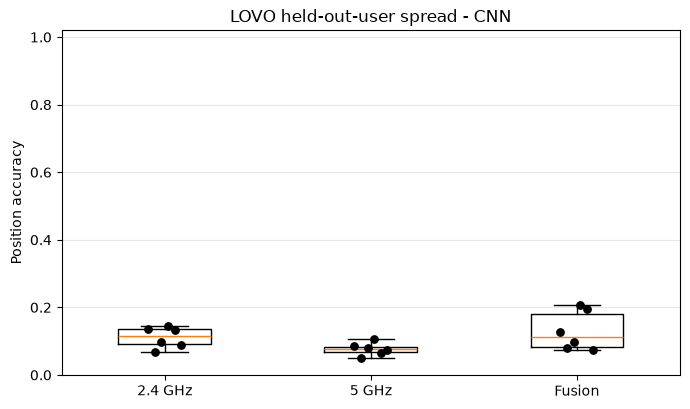

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_seed-42/block_vs_lovo_cnn_seed-42.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


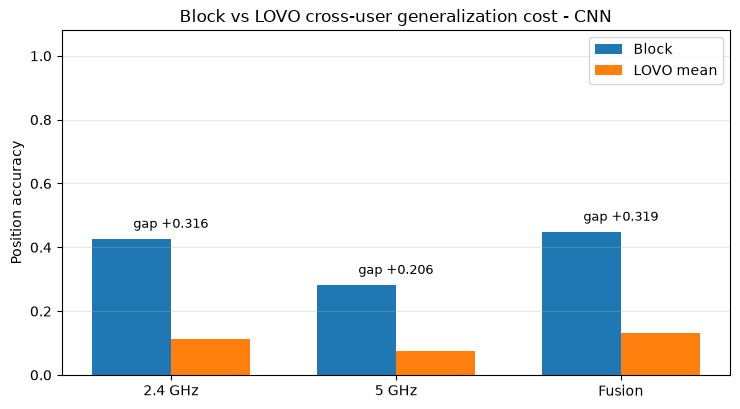

,model,dataset,position_accuracy_mean_std,macro_f1_mean_std,room_accuracy_mean_std,mean_distance_error_mean_std,median_distance_error_mean_std,rmse_distance_error_mean_std,p90_distance_error_mean_std,majority_position_accuracy_mean_std,majority_room_accuracy_mean_std
0,CNN,2.4 GHz,0.1111 +/- 0.0305,0.0905 +/- 0.0245,0.6139 +/- 0.1043,4.1391 +/- 0.4152,3.3422 +/- 0.4423,5.3161 +/- 0.5491,9.3387 +/- 1.2433,0.0207 +/- 0.0011,0.6514 +/- 0.0134
1,CNN,5 GHz,0.0763 +/- 0.0190,0.0538 +/- 0.0212,0.6501 +/- 0.1271,3.8768 +/- 0.6803,3.4431 +/- 0.4170,4.7370 +/- 0.8420,7.6255 +/- 1.7714,0.0196 +/- 0.0003,0.6557 +/- 0.0037
2,CNN,Fusion,0.1301 +/- 0.0588,0.1055 +/- 0.0450,0.6542 +/- 0.1279,3.7493 +/- 0.6941,2.9884 +/- 0.5326,4.8821 +/- 0.9099,8.3812 +/- 1.7739,0.0201 +/- 0.0012,0.6521 +/- 0.0134


,model,dataset,held_out_user,position_accuracy,samples,seed
0,CNN,2.4 GHz,01,0.136943,1570,42
1,CNN,2.4 GHz,02,0.068600,1414,42
2,CNN,2.4 GHz,03,0.096408,1587,42
3,CNN,2.4 GHz,04,0.143590,1560,42
4,CNN,2.4 GHz,05,0.131898,1486,42
5,CNN,2.4 GHz,06,0.089216,1289,42
6,CNN,5 GHz,01,0.084767,1628,42
7,CNN,5 GHz,02,0.048811,1598,42
8,CNN,5 GHz,03,0.080545,1614,42
9,CNN,5 GHz,04,0.105199,1635,42


In [10]:
if "lovo" in SPLIT_MODES:
    lovo_predictions = all_cnn_predictions.loc[
        all_cnn_predictions["split_mode"].eq("lovo")
    ].copy()
    lovo_per_fold = (
        lovo_predictions.assign(
            position_correct=lambda frame: frame["true_position"].eq(
                frame["pred_position"]
            )
        )
        .groupby(["model", "dataset", "held_out_user"], as_index=False, sort=True)
        .agg(
            position_accuracy=("position_correct", "mean"),
            samples=("position_correct", "size"),
        )
    )
    lovo_per_fold["seed"] = ANALYSIS_SEED
    lovo_summary = cnn_analysis_summary.loc[
        cnn_analysis_summary["split"].eq("lovo")
    ].copy()
    lovo_table = lovo_aggregated_analysis_table(lovo_summary)

    plot_lovo_fold_spread(
        lovo_per_fold,
        bands=ANALYSIS_BANDS,
        model=ANALYSIS_MODEL,
        save_path=(
            analysis_plots_dir
            / f"lovo_{_slugify(ANALYSIS_MODEL)}_fold_spread_seed-{ANALYSIS_SEED}.png"
        ),
    )
    plot_block_vs_lovo_position_accuracy(
        cnn_master_table,
        lovo_summary,
        bands=ANALYSIS_BANDS,
        model=ANALYSIS_MODEL,
        save_path=(
            analysis_plots_dir
            / f"block_vs_lovo_{_slugify(ANALYSIS_MODEL)}_seed-{ANALYSIS_SEED}.png"
        ),
    )

    display(lovo_table)
    display(lovo_per_fold)
else:
    print("LOVO analysis skipped because 'lovo' is not in SPLIT_MODES.")


### Analysis Figures

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_seed-42/cdf_by_model_2-4-ghz.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


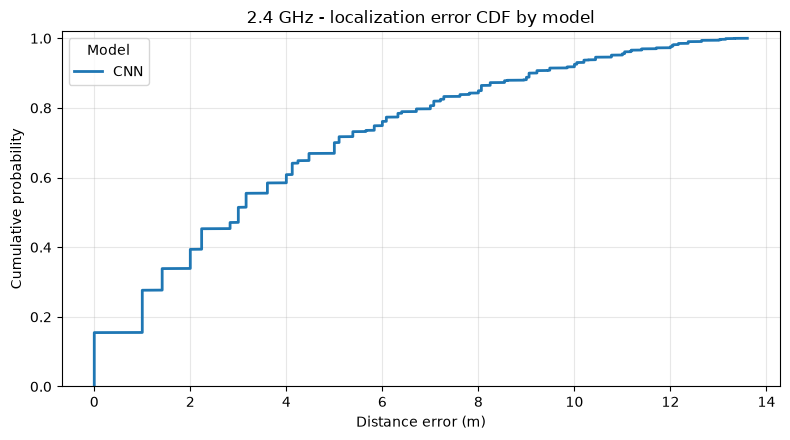

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_seed-42/cdf_by_model_5-ghz.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


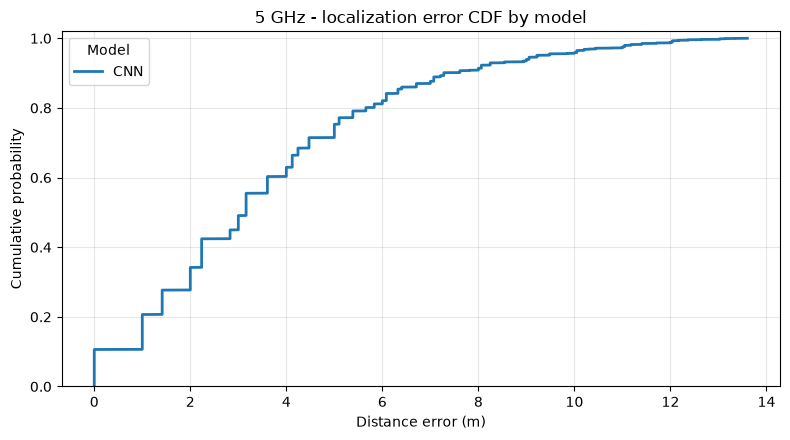

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_seed-42/cdf_by_model_fusion.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


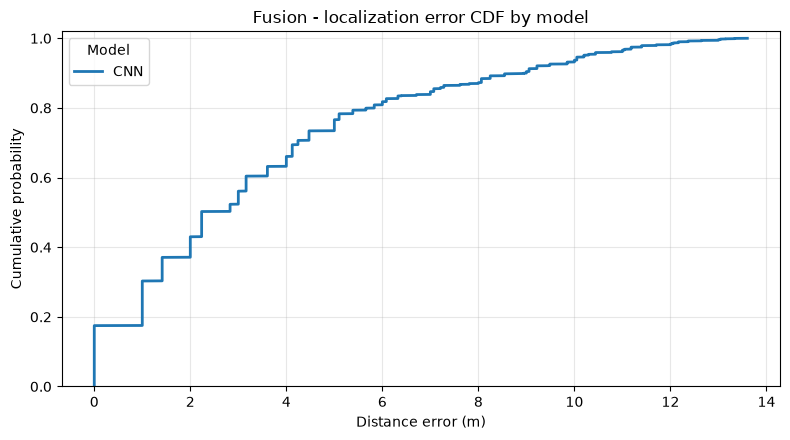

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_seed-42/cdf_cnn_all-bands_block.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


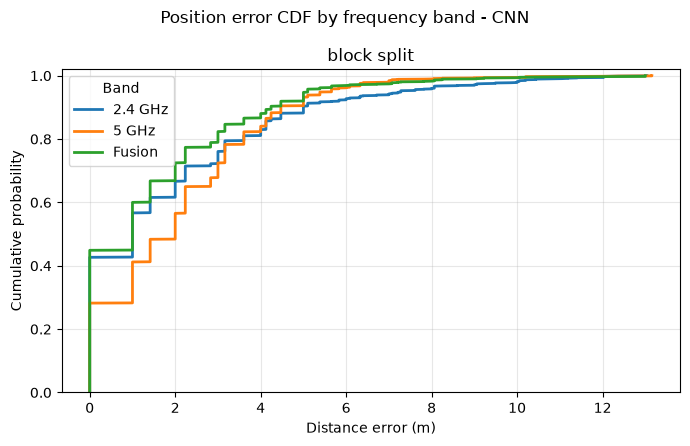

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_seed-42/cdf_cnn_all-bands_lovo.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


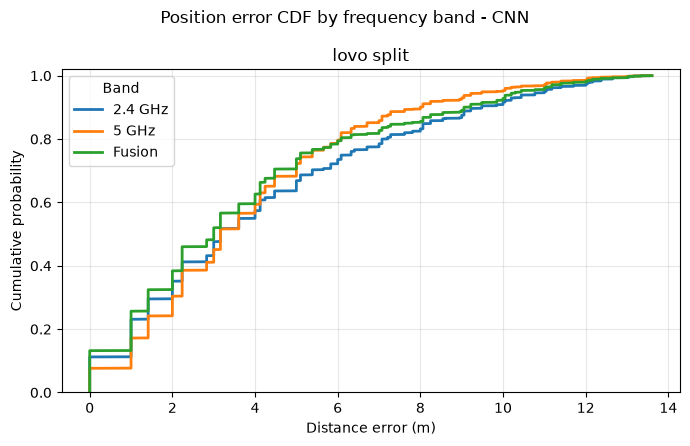

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_seed-42/boxplot_cnn_band_distance_error.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


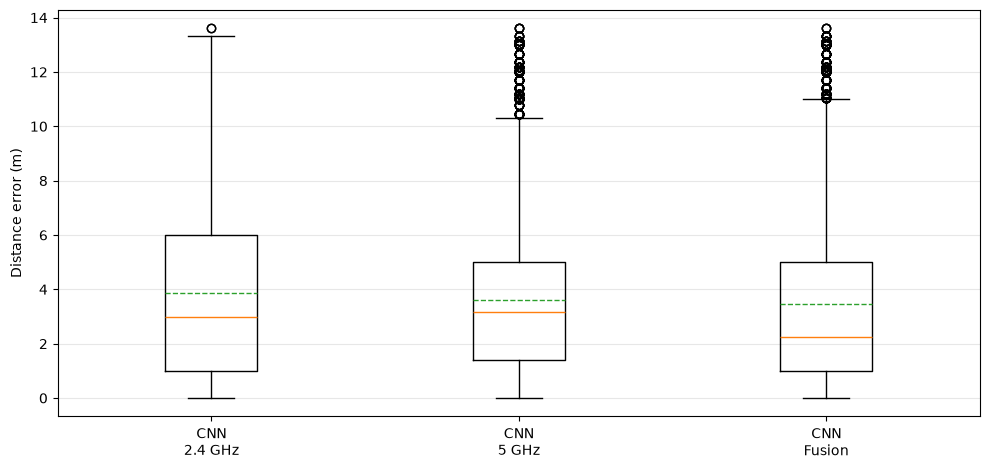

In [11]:
if SHOW_CDF_BY_BAND:
    for band in ANALYSIS_BANDS:
        plot_localization_error_cdf_by_model(
            all_cnn_predictions,
            dataset=band,
            save_path=analysis_plots_dir / f"cdf_by_model_{_slugify(band)}.png",
        )

if SHOW_CDF_BY_MODEL:
    plot_band_error_cdf(
        all_cnn_predictions,
        model_label=ANALYSIS_MODEL,
        split_modes=SPLIT_MODES,
        band_order=ANALYSIS_BANDS,
        save_path=analysis_plots_dir,
    )

if SHOW_BOXPLOT:
    plot_model_band_error_boxplot(
        all_cnn_predictions,
        models=(ANALYSIS_MODEL,),
        bands=ANALYSIS_BANDS,
        save_path=(
            analysis_plots_dir
            / f"boxplot_{_slugify(ANALYSIS_MODEL)}_band_distance_error.png"
        ),
    )


### Confusion Matrix and Floor Plan

Confusion/floor-plan model: CNN on Fusion (block, seed 42)
[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_seed-42/floor_plan_fusion_cnn_block_seed-42.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


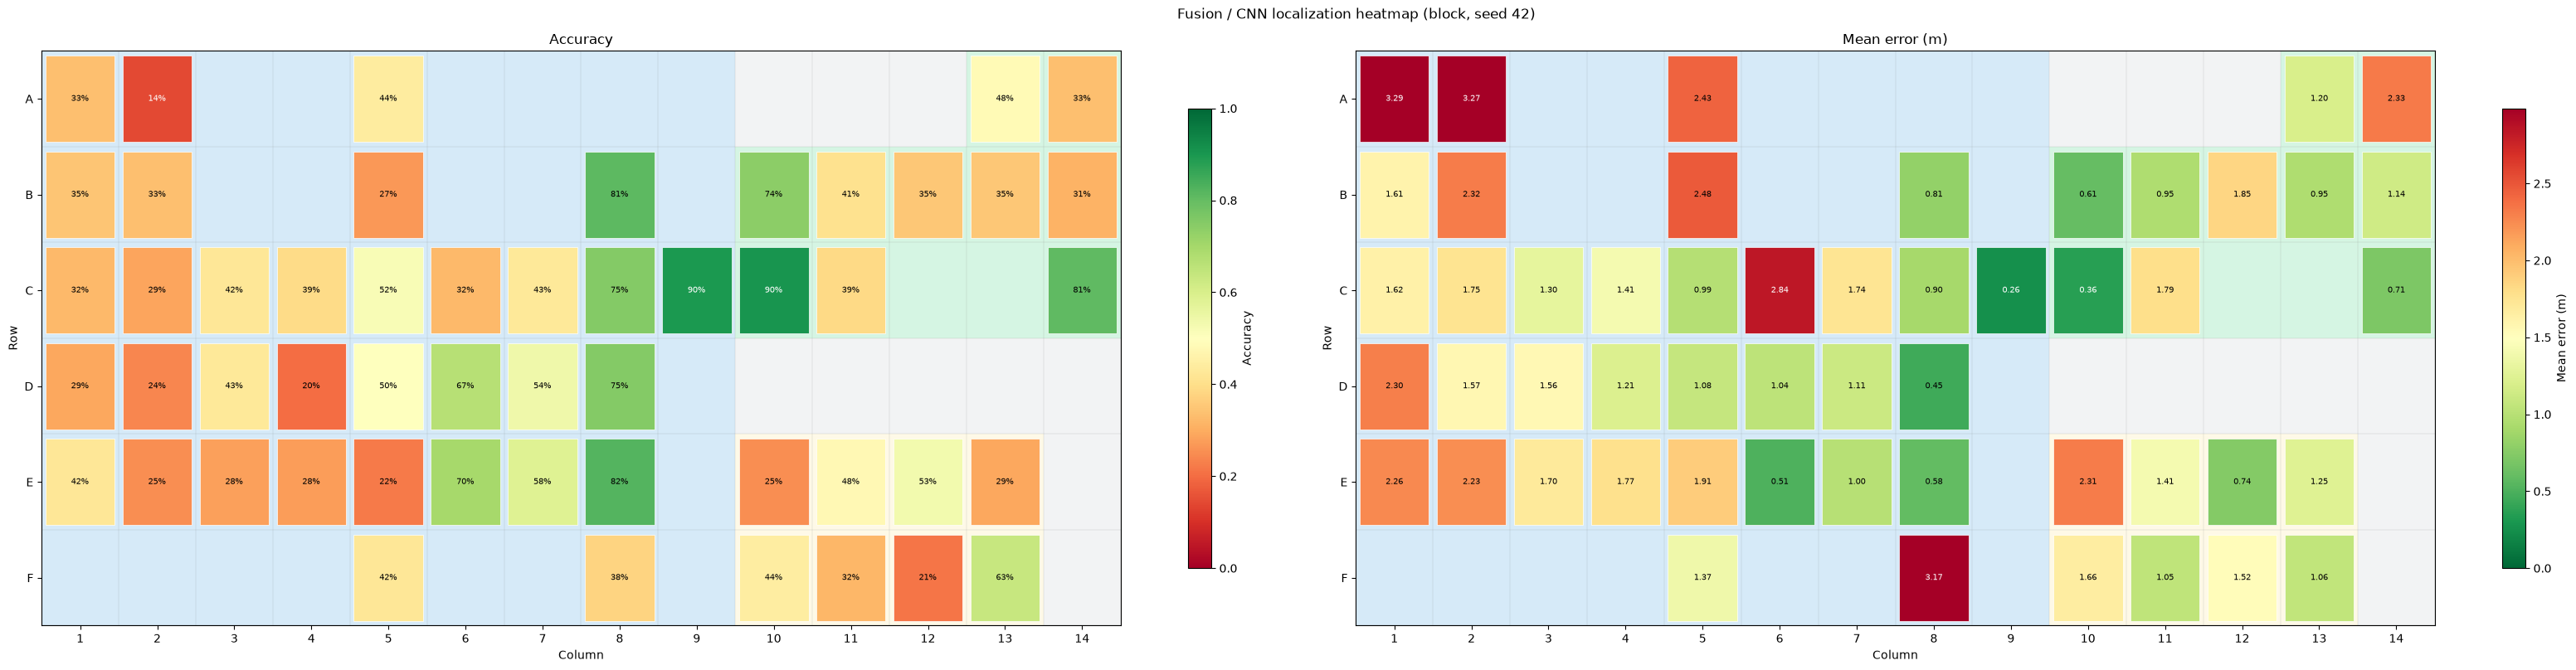

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_seed-42/confusion_fusion_cnn_block_seed-42.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


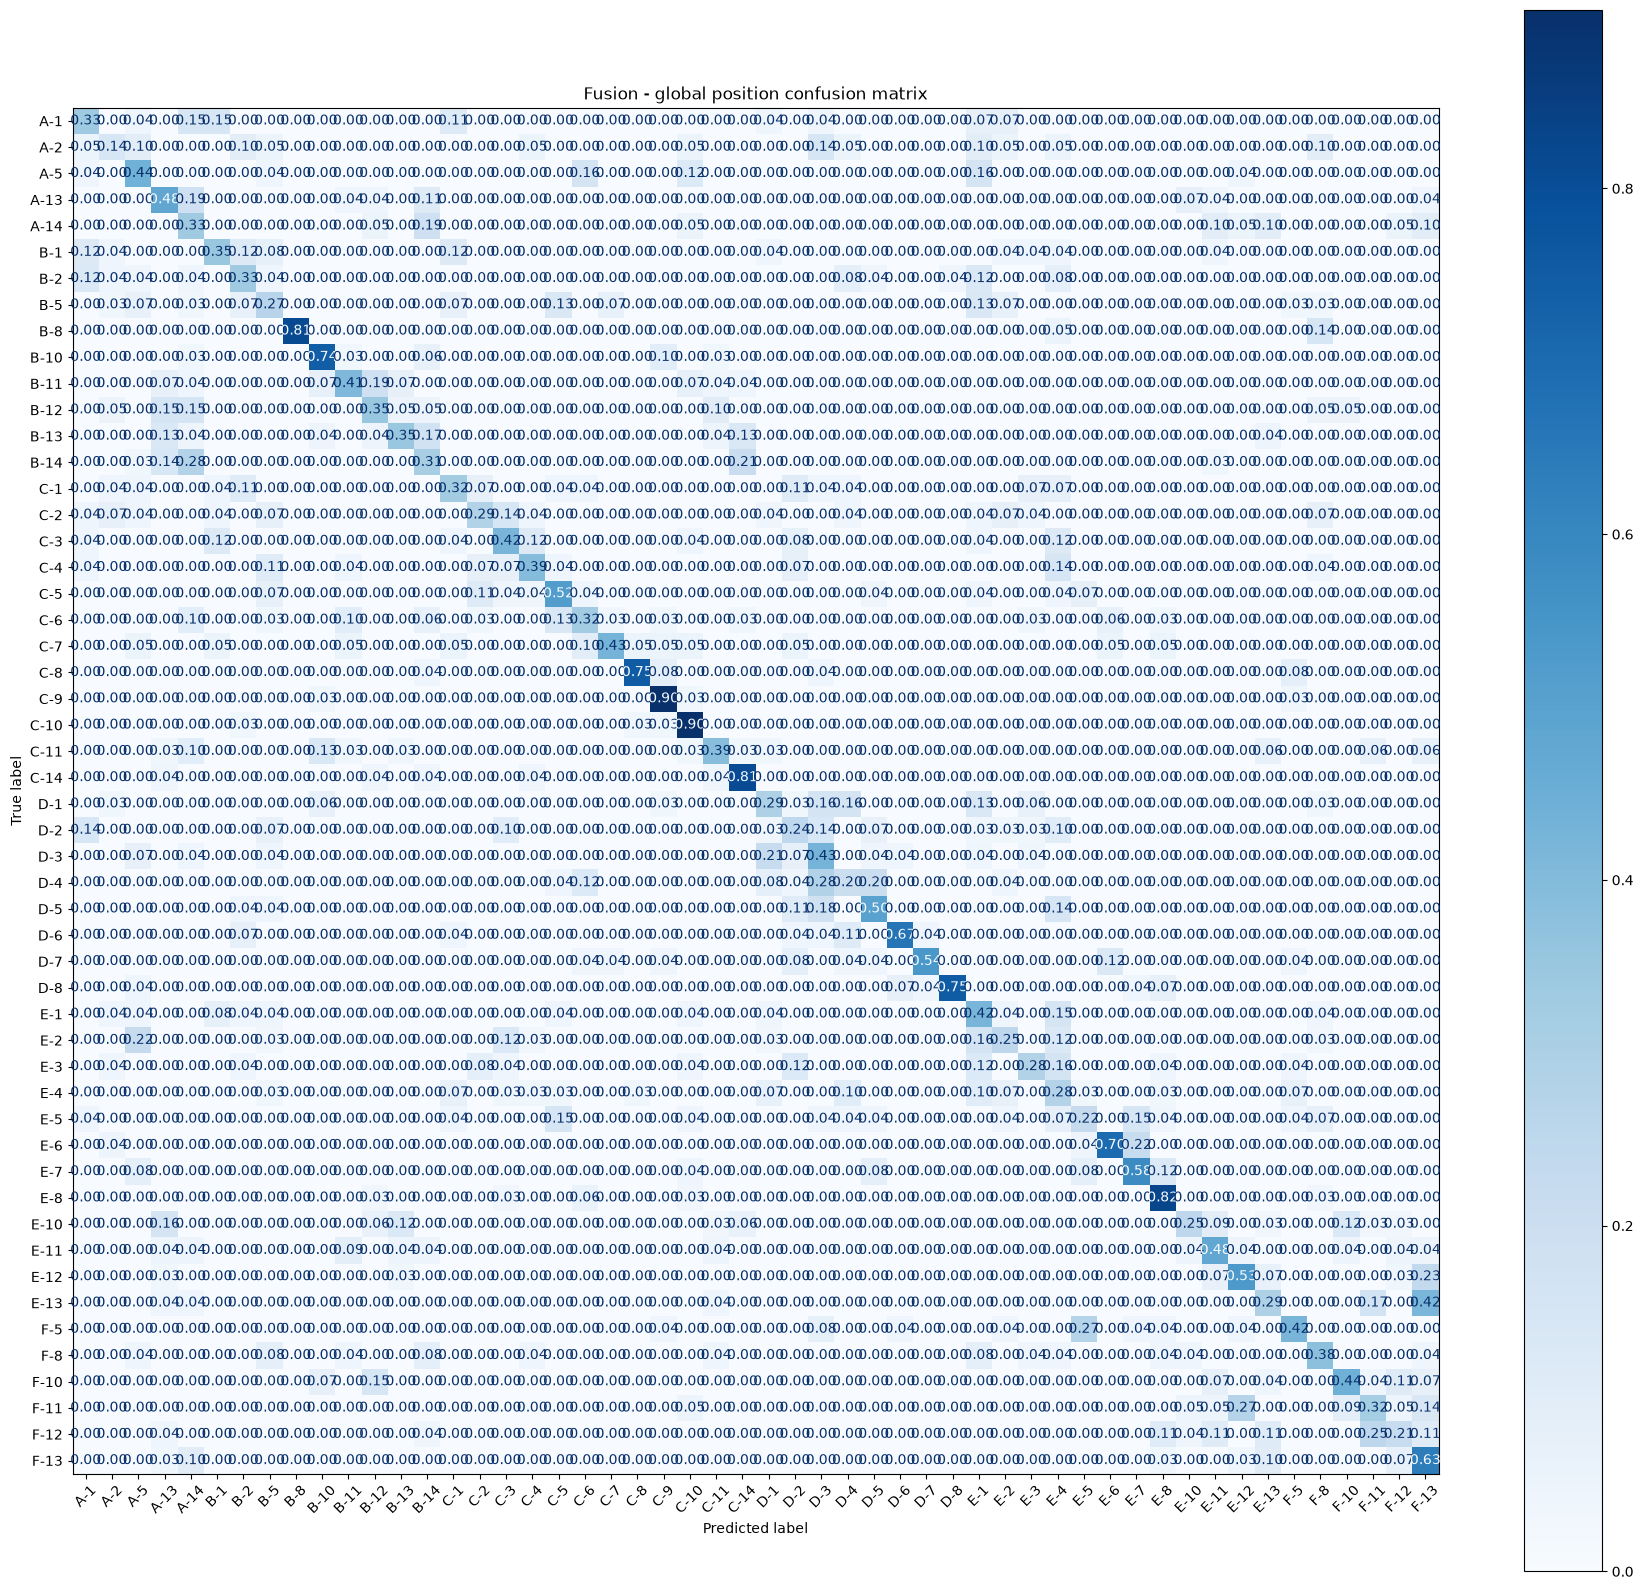

In [12]:
confusion_model, confusion_predictions = best_confusion_predictions(
    all_cnn_predictions,
    cnn_master_table,
    dataset=CONFUSION_DATASET,
    model=ANALYSIS_MODEL,
    split=CONFUSION_SPLIT,
)
print(
    f"Confusion/floor-plan model: {confusion_model} on {CONFUSION_DATASET} "
    f"({CONFUSION_SPLIT}, seed {ANALYSIS_SEED})"
)

figure_stem = (
    f"{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}_"
    f"{CONFUSION_SPLIT}_seed-{ANALYSIS_SEED}"
)
if SHOW_FLOOR_PLAN:
    plot_floor_plan_heatmap(
        confusion_predictions,
        title=(
            f"{CONFUSION_DATASET} / {confusion_model} localization heatmap "
            f"({CONFUSION_SPLIT}, seed {ANALYSIS_SEED})"
        ),
        save_path=analysis_plots_dir / f"floor_plan_{figure_stem}.png",
    )

if SHOW_CONFUSION_MATRICES:
    plot_global_position_confusion_matrix(
        confusion_predictions,
        dataset=CONFUSION_DATASET,
        normalize="true",
        save_path=analysis_plots_dir / f"confusion_{figure_stem}.png",
    )
    if SHOW_PER_ROOM_PLOTS:
        room_plot_dir = analysis_plots_dir / f"confusion_by_room_{figure_stem}"
        plot_position_confusion_by_true_room(
            confusion_predictions,
            dataset=CONFUSION_DATASET,
            normalize="true",
            save_path=room_plot_dir,
        )
